# Ayudantía 12 de Marzo de 2026

## - Taller de Herramientas Computacionales

### - Antonio Guerrero

## Repaso de la Clase del Profesor: Tipos de datos

In [55]:
# Variables y espacios de memoria

a = 256
b = 256

print(a == b)
print(a is b)

a = 257
b = 257

print(a == b)
print(a is b)

True
True
True
False


In [ ]:
# Lista

lista = [1, 2, 3, "name"]

# Array

array = [5,2]

In [57]:
array=[5,2]

print(array)

array.append(7)

print(array)

[5, 2]
[5, 2, 7]


In [59]:
lista = [[0]]*3
lista[0][0] = 5
print(lista)

[[5], [5], [5]]


In [69]:
s = {1, True}

print(s)

{1}


### Listas comprimidas
$$\{ x^{2} \mid x \in \mathbb{N}, x \text{ es par y hasta 10} \}$$

In [75]:
# Sintaxis del if

a = 10

if a==1:
    print("a es 1")
elif a==10:
    print("a es 10")

# Sintaxis for

for i in range(1,10):
    print(i)

# Sintaxis

error = 1.0
while error > 0.01:
    error /= 2
    print(error)

a es 10
1
2
3
4
5
6
7
8
9
0.5
0.25
0.125
0.0625
0.03125
0.015625
0.0078125


## Implementar el cálculo de una parabola

Fórmula general de la parábola: $Y = Bx^2 + C$

Generar las x

x = range(1, 100)
Definir
B= 2.2
C= 1.2

Calcular Y con ciclos For y Lists Comprehension

e imprimir en matplotlib

In [81]:
y = []
x_list = []

for x in range(1,101):
    y_save = ((x**2)*2.2) + 1.2
    y.append(y_save)
    x_list.append(x)

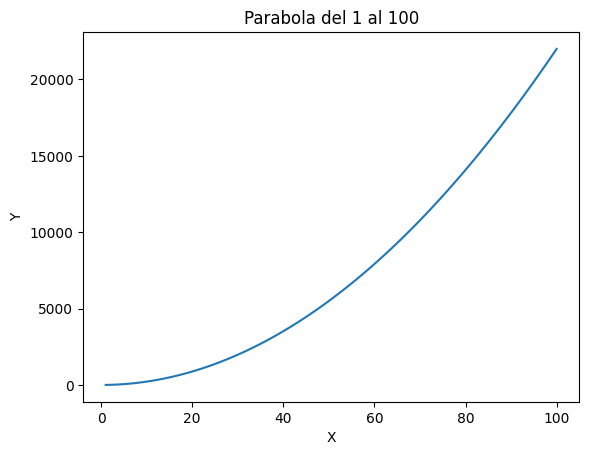

In [83]:
import matplotlib.pyplot as plt

plt.plot(x_list,y)
plt.title("Parabola del 1 al 100")
plt.xlabel("X")
plt.ylabel("Y")

plt.show()

# Ejercicio: Dinámica Poblacional de *Paramecium caudatum*

En este ejercicio estudiaremos el crecimiento de una población de **paramecios** (*Paramecium caudatum*).

En la década de 1930, el biólogo Georgy Gause utilizó paramecios para demostrar que una población no crece indefinidamente. Al inicio, cuentan con recursos abundantes y crecen rápido, pero conforme la densidad aumenta, la competencia por comida frena el crecimiento hasta alcanzar un equilibrio.

### La dinámica
La dinámica está gobernada por la **Ecuación de Verhulst**:

$$\frac{dP}{dt} = rP \left( 1 - \frac{P}{K} \right)$$

Donde:
* **$P$**: Densidad de la población (individuos/ml).
* **$r$**: Tasa de crecimiento intrínseca (potencial biótico).
* **$K$**: Capacidad de carga (el límite de individuos que el medio soporta).

Mediante el método de separación de variables, la **solución analítica** exacta para una población inicial $P_0$ es:

$$P(t) = \frac{K \cdot P_0 \cdot e^{rt}}{K + P_0(e^{rt} - 1)}$$

---
### Instrucciones de la Práctica
1. **Solución de la Pob**: Genera la curva teórica usando una *List Comprehension*.
2. **Visualización**: Grafica el resultado para ver el tiempo.

### Las Variable

| Variable | Valor | Qué es |
| :--- | :--- | :--- |
| **$K$** | `500` | **Capacidad de carga:** Representa el número máximo de individuos que pueden sobrevivir en 1 ml de medio de cultivo basándose en la disponibilidad de alimento (bacterias) y espacio. |
| **$P_0$** | `5` | **Población inicial:** Es el "inóculo" inicial. Empezamos con una densidad baja para observar toda la fase de aceleración logarítmica antes de que la competencia frene el crecimiento. |
| **$r$** | `0.25` | **Tasa intrínseca:** Indica que, en condiciones ideales, la población tiene el potencial de crecer un 25% cada hora. Es un valor estándar para microorganismos ciliados en temperaturas de laboratorio (aprox. 25°C). |
| **$dt$** | `0.5` | **Paso de tiempo:** En el método de Euler, un $dt$ pequeño es vital. Usar 0.5 (media hora) asegura que la aproximación lineal no se "dispare" y sea lo suficientemente suave para seguir la curva teórica. |

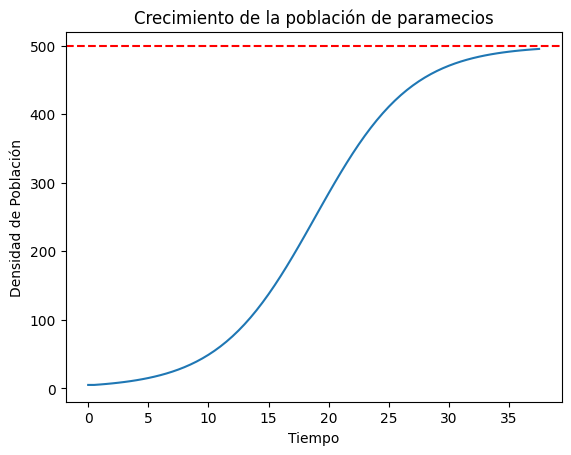

In [88]:
# Solución de ejercicio sobre crecimiento de paramecios

import math
import matplotlib.pyplot as plt

#Variables estaticas
K = 500
P0 = 5
r = 0.25
dt = 0.5

#Listas
Pt = [P0]
t_list = [0]

#Variable auxiliar
P_actual = P0
i = 0


while P_actual < K * 0.99:
    P_actual = (K*P0*math.exp(r*t_list[i]))/(K + P0*(math.exp(r*t_list[i])-1))
    Pt.append(P_actual)
    t_list.append(t_list[i]+dt)
    i = i+1


plt.plot(t_list,Pt)
plt.axhline(y=K, color='red',linestyle='--',label='Capacidad de carga')
plt.title("Crecimiento de la población de paramecios")
plt.xlabel("Tiempo")
plt.ylabel("Densidad de Población")

plt.show()


# Ejercicio 3: Farmacocinética de la Gentamicina

La **Gentamicina** es un antibiótico crítico cuyo exceso en el flujo sanguíneo puede causar ototoxicidad (daño auditivo) o nefrotoxicidad (daño renal). Para garantizar la seguridad del paciente, se debe esperar a que el fármaco sea eliminado naturalmente hasta un nivel seguro antes de administrar una nueva dosis.

### Las Mates
La velocidad de eliminación del fármaco sigue una **Ecuación Diferencial Ordinaria (EDO)** de primer orden:

$$\frac{dC}{dt} = -kC$$

Donde:
* **$C$**: Concentración del fármaco en sangre (mg/L).
* **$k$**: Constante de eliminación ($h^{-1}$), que representa la fracción del fármaco eliminada por unidad de tiempo.

### Solución Analítica (Decaimiento Exponencial)
Al resolver la EDO, obtenemos la ecuación que usaremos en nuestra simulación:

$$C(t) = C_0 e^{-kt}$$

* **$C_0$**: Concentración inicial (pico) medida tras la administración.
* **$e$**: Número de Euler ($\approx 2.71828$).

---
### Instrucciones y Variables a usar:
Para este análisis clínico, utilizaremos los siguientes parámetros:

1. **`C0 = 12.0`**: Concentración pico inicial en mg/L.
2. **`k = 0.18`**: Constante de eliminación (basada en la función renal del paciente).
3. **`umbral_seguro = 1.5`**: Nivel de concentración (mg/L) por debajo del cual es seguro proceder.
4. **`dt = 1`**: Paso de tiempo de una hora para la simulación.

**Instrucciones:** Crea un ciclo `for` que determine cuántas horas deben transcurrir para que la concentración sea menor o igual al `umbral_seguro`y plotealo si deseas
